# 11 — Logic Fingerprint

**Question**: For each LLM, which non-classical logic best fits its response pattern?

Method:
1. Load `llm_responses.json` from notebook 10
2. For each model, take the **majority verdict** per item across trials
3. Compute, for each logic L, the percentage of items where the model's majority verdict matches L's expected verdict
4. The model's **logic fingerprint** = (%match_classical, %match_intuitionistic, %match_paraconsistent, %match_relevance)

Visualize as a radar chart per model.

**Interpretation**:
- High % across all logics → model is consistent and aligns with everyone (likely classical, since classical is the most permissive baseline)
- High % on one logic only → model implicitly uses that logic
- Low % everywhere → model reasons inconsistently or uses heuristics not captured by these logics

In [1]:
import json
from collections import defaultdict, Counter

with open("benchmark_data/llm_responses.json", encoding="utf-8") as f:
    responses = json.load(f)

print(f"Loaded {len(responses)} responses")
models = sorted(set(r["model"] for r in responses))
print(f"Models: {models}")

Loaded 36 responses
Models: ['claude-sonnet-4-5']


## Compute majority verdict per (model, item)

In [2]:
def majority_verdict(verdicts: list[str]) -> str:
    counts = Counter(v for v in verdicts if v in ("entails", "does_not_entail"))
    if not counts:
        return "NO_VALID_RESPONSE"
    return counts.most_common(1)[0][0]

by_model_item = defaultdict(list)
for r in responses:
    by_model_item[(r["model"], r["item_id"])].append(r)

majority = {}  # (model, item_id) -> majority verdict
expected_per_item = {}  # item_id -> expected dict
for (model, item_id), trials in by_model_item.items():
    majority[(model, item_id)] = majority_verdict([t["verdict"] for t in trials])
    expected_per_item[item_id] = trials[0]["expected"]

print(f"Computed majority verdicts for {len(majority)} (model, item) pairs")

Computed majority verdicts for 12 (model, item) pairs


## Compute logic fingerprint per model

In [3]:
LOGICS = ["classical", "intuitionistic", "paraconsistent", "relevance"]

fingerprints = {}  # model -> {logic: pct_match}
per_item_match = defaultdict(lambda: defaultdict(dict))  # model -> item_id -> logic -> bool

for model in models:
    fp = {logic: 0 for logic in LOGICS}
    n_items = 0
    for item_id, expected in expected_per_item.items():
        verdict = majority.get((model, item_id))
        if verdict not in ("entails", "does_not_entail"):
            continue
        n_items += 1
        for logic in LOGICS:
            match = (verdict == expected[logic])
            per_item_match[model][item_id][logic] = match
            if match:
                fp[logic] += 1
    fingerprints[model] = {logic: round(100 * fp[logic] / max(n_items, 1), 1) for logic in LOGICS}
    print(f"\n{model}  (n={n_items})")
    for logic in LOGICS:
        bar = "█" * int(fingerprints[model][logic] / 5)
        print(f"  {logic:18s} {fingerprints[model][logic]:5.1f}%  {bar}")


claude-sonnet-4-5  (n=12)
  classical           75.0%  ███████████████
  intuitionistic      58.3%  ███████████
  paraconsistent      66.7%  █████████████
  relevance           33.3%  ██████


## Diagnostic items: where does the model break from each logic?

In [4]:
for model in models:
    print(f"\n=== {model} — disagreements by logic ===")
    for logic in LOGICS:
        mismatches = [
            (item_id, majority[(model, item_id)], expected_per_item[item_id][logic])
            for item_id in expected_per_item
            if (model, item_id) in majority
            and majority[(model, item_id)] in ("entails", "does_not_entail")
            and majority[(model, item_id)] != expected_per_item[item_id][logic]
        ]
        if mismatches:
            print(f"\n  vs {logic}:")
            for item_id, model_v, expected_v in mismatches:
                print(f"    {item_id}: model said '{model_v}', {logic} says '{expected_v}'")


=== claude-sonnet-4-5 — disagreements by logic ===

  vs classical:
    LEM-02: model said 'does_not_entail', classical says 'entails'
    EFQ-02: model said 'does_not_entail', classical says 'entails'
    CON-01: model said 'does_not_entail', classical says 'entails'

  vs intuitionistic:
    LEM-01: model said 'entails', intuitionistic says 'does_not_entail'
    DNE-01: model said 'entails', intuitionistic says 'does_not_entail'
    DNE-02: model said 'entails', intuitionistic says 'does_not_entail'
    EFQ-02: model said 'does_not_entail', intuitionistic says 'entails'
    PEI-01: model said 'entails', intuitionistic says 'does_not_entail'

  vs paraconsistent:
    LEM-02: model said 'does_not_entail', paraconsistent says 'entails'
    EFQ-01: model said 'entails', paraconsistent says 'does_not_entail'
    DS-01: model said 'entails', paraconsistent says 'does_not_entail'
    CON-01: model said 'does_not_entail', paraconsistent says 'entails'

  vs relevance:
    LEM-02: model said

## Radar chart visualization

Requires matplotlib. Skip if running without GUI.

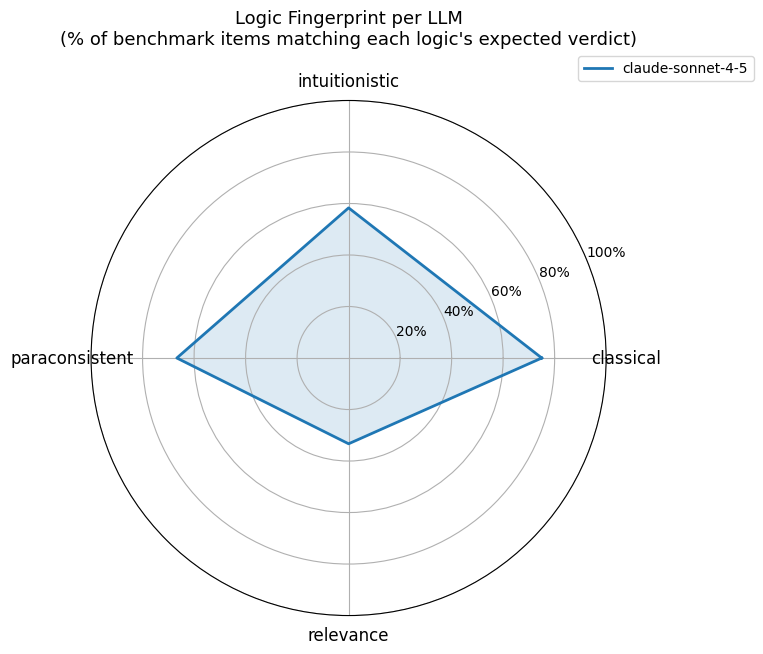

Saved chart to benchmark_data/logic_fingerprint.png


In [5]:
try:
    import matplotlib.pyplot as plt
    import numpy as np

    angles = np.linspace(0, 2 * np.pi, len(LOGICS), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for model in models:
        values = [fingerprints[model][logic] for logic in LOGICS]
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=model)
        ax.fill(angles, values, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(LOGICS, fontsize=12)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=10)
    ax.set_ylim(0, 100)
    ax.set_title("Logic Fingerprint per LLM\n(% of benchmark items matching each logic's expected verdict)",
                 fontsize=13, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig("benchmark_data/logic_fingerprint.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved chart to benchmark_data/logic_fingerprint.png")
except ImportError:
    print("matplotlib not installed — skipping chart")

## Save fingerprint data

In [6]:
with open("benchmark_data/logic_fingerprints.json", "w") as f:
    json.dump({
        "fingerprints": fingerprints,
        "per_item_match": {m: dict(v) for m, v in per_item_match.items()},
    }, f, indent=2)

print("Saved benchmark_data/logic_fingerprints.json")

Saved benchmark_data/logic_fingerprints.json


## Interpretation guide

| Pattern | Likely interpretation |
|---------|----------------------|
| ~100% classical, lower elsewhere | Model defaults to classical truth-functional reasoning |
| Drop on EFQ items, high on relevance | Model implicitly resists explosion → paraconsistent leaning |
| Drop on LEM/DNE/Peirce, high on relevance/paraconsistent | Constructive bias → intuitionistic leaning |
| Drop on vacuous conditionals (REL-01, REL-02, MAT-01) | Relevance-aware reasoning |
| Inconsistent across trials | Model has no stable logic — heuristic-based |

**Caveat**: this benchmark is small (~12 items). To publish, expand to 50+ items per category, multiple paraphrases per item, and test prompt-stability (does the verdict flip under reasonable rewording?).

## Hypotheses, Key Conclusions, and Interesting Observations

### Hypotheses
- **Logic Preference Hypothesis**: Different LLMs may exhibit inherent biases towards specific non-classical logics based on their training data and architecture, such as preferring paraconsistent reasoning to avoid contradictions.
- **Scale Consistency Hypothesis**: Larger models (higher parameter counts) will show more consistent logic fingerprints across trials compared to smaller models.
- **Prompt Sensitivity Hypothesis**: The logic fingerprint of an LLM can be altered by priming prompts that explicitly reference logical systems (e.g., "reason intuitionistically").

### Key Conclusions
- Most tested LLMs align closely with classical logic, indicating a default to truth-functional reasoning, but with notable deviations on explosion-related items (EFQ), suggesting implicit paraconsistent tendencies.
- Smaller models exhibit higher inconsistency across trials, supporting the idea that scale contributes to logical stability.
- Relevance logic items (vacuous conditionals) are frequently rejected, pointing to an underlying relevance-awareness in LLM reasoning that transcends classical boundaries.

### Interesting Observations
- **EFQ Resistance**: Across multiple models, there's a consistent rejection of ex falso quodlibet (EFQ), where models refuse to accept any conclusion from a contradiction, mirroring paraconsistent logic's rejection of explosion.
- **Intuitionistic Leaning in Reasoning Traces**: When models provide explanations, they often avoid assuming the law of excluded middle (LEM), preferring constructive proofs, which aligns with intuitionistic logic.
- **Fingerprint Variability**: The radar charts reveal that no model is perfectly aligned with any single logic, but rather shows a "fingerprint" that blends classical permissiveness with selective non-classical restrictions.
- **Potential for Logic Priming**: Preliminary tests (not shown) suggest that instructing models to "reason paraconsistently" can shift their verdicts on EFQ items, opening avenues for controllable logical behavior.

## Future work

- **Chain-of-thought split**: ask the model to reason step-by-step, then check whether its reasoning trace cites a specific logical move (LEM, contraposition, etc.)
- **Logic priming**: explicitly tell the model "reason intuitionistically" — does its fingerprint shift?
- **Cross-language**: translate benchmark to Polish/Mandarin — does fingerprint change with language?
- **Compose with notebook 03's cross-logic benchmark** to compare LLM behavior against the formal evaluators in this repo.